# CNG403 Assignment 2 — Personal Face Authentication

**Objective**: Fine-tune a pretrained ResNet18 to classify face images as **YOU** or **NOT YOU**, evaluate it with proper metrics, and deploy it as a Gradio web application.

**You should read, anlayse, debug and undestand the whole codebase NOT just your tasks** 

**Workflow**:
1. [Setup](#1-setup)
2. [Dataset](#2-dataset)
3. [Model](#3-model)
4. [Training](#4-training)
5. [Evaluation](#5-evaluation)
6. [Gradio App](#6-gradio-app)

## 1. Setup

In [13]:
import sys, os
sys.path.insert(0, 'src')   # make src/ importable

import json
import numpy as np
import matplotlib.pyplot as plt
import torch

print('PyTorch version :', torch.__version__)
print('Device          :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.12.0+cpu
Device          : cpu


In [14]:
with open('config.json') as f:
    cfg = json.load(f)

print('Configuration:', json.dumps(cfg, indent=2))

# Seed is fixed — do not change
SEED = cfg['training']['seed']
print(f'\nRandom seed: {SEED}  (do not change)')

Configuration: {
  "training": {
    "batch_size": 16,
    "epochs": 20,
    "learning_rate": 0.001,
    "seed": 42,
    "patience": 7
  },
  "model": {
    "backbone": "resnet18",
    "pretrained": true,
    "num_classes": 2
  },
  "data": {
    "image_size": 224,
    "positive_dir": "data/positive",
    "negative_dir": "data/negative",
    "checkpoint_dir": "checkpoints",
    "log_dir": "logs"
  }
}

Random seed: 42  (do not change)


## 2. Dataset

The negative class is **fixed** for all students: 5 LFW identities, each contributing
4 train / 1 val / 1 test image (20 negatives per split).  
Run the cell below **once** to download and save them automatically.

### 2.1 Download negative class

In [15]:
from dataset import download_negative_class, NEGATIVE_IDENTITIES, NEGATIVE_SPLIT

print(NEGATIVE_IDENTITIES)

download_negative_class(save_dir=cfg['data']['negative_dir'])

print('\nFixed negative identities:')
for name in NEGATIVE_IDENTITIES:
    print(f'  {name}')
print(f'\nSplit indices: {NEGATIVE_SPLIT}')

['Serena Williams', 'Angelina Jolie', 'Alejandro Toledo', 'Recep Tayyip Erdogan', 'George W Bush']
Negative class already downloaded (30 images in data\negative). Skipping.

Fixed negative identities:
  Serena Williams
  Angelina Jolie
  Alejandro Toledo
  Recep Tayyip Erdogan
  George W Bush

Split indices: {'train': [0, 1, 2, 3], 'val': [4], 'test': [5]}


### 2.2 Add your positive images

Place **30 photos of your own face** into the following folders:

```
data/positive/
    train/   <-- 20 images
    val/     <-- 5  images
    test/    <-- 5  images   ⚠️  DO NOT use these in training or validation
```

Any resolution is fine — images are resized to 224×224 automatically.  
**Do not mix up the splits.** Using test images in training or validation will result in a zero grade.

### 2.3 Sanity checks

In [16]:
from pathlib import Path

pos_dir = Path(cfg['data']['positive_dir'])
neg_dir = Path(cfg['data']['negative_dir'])
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

def count_images(folder):
    folder = Path(folder)
    return sum(1 for p in folder.iterdir() if p.suffix in IMAGE_EXTS)

expected = {'train': (20, 20), 'val': (5, 5), 'test': (5, 5)}
all_ok = True

print(f"{'Split':<8} {'Positive':>10} {'Negative':>10} {'Status':>8}")
print('-' * 42)
for split, (exp_pos, exp_neg) in expected.items():
    n_pos = count_images(pos_dir / split)
    n_neg = count_images(neg_dir / split)
    ok = (n_pos == exp_pos) and (n_neg == exp_neg)
    if not ok:
        all_ok = False
    status = '✓' if ok else '✗'
    print(f'{split:<8} {n_pos:>10} {n_neg:>10} {status:>8}')

if not all_ok:
    print('\n⚠ Some counts are wrong. Check your data/positive/ folders before continuing.')
else:
    print('\nAll image counts correct.')

Split      Positive   Negative   Status
------------------------------------------
train            20         20        ✓
val               5          5        ✓
test              5          5        ✓

All image counts correct.


In [17]:
# ⚠️  DATA LEAKAGE CHECK — this check will also be run by the grader.
# If any test image appears in train/ or val/, an AssertionError is raised.
from dataset import check_no_test_leakage

check_no_test_leakage(cfg['data']['positive_dir'])

 No test-image leakage detected.


### 2.4 Visualize samples

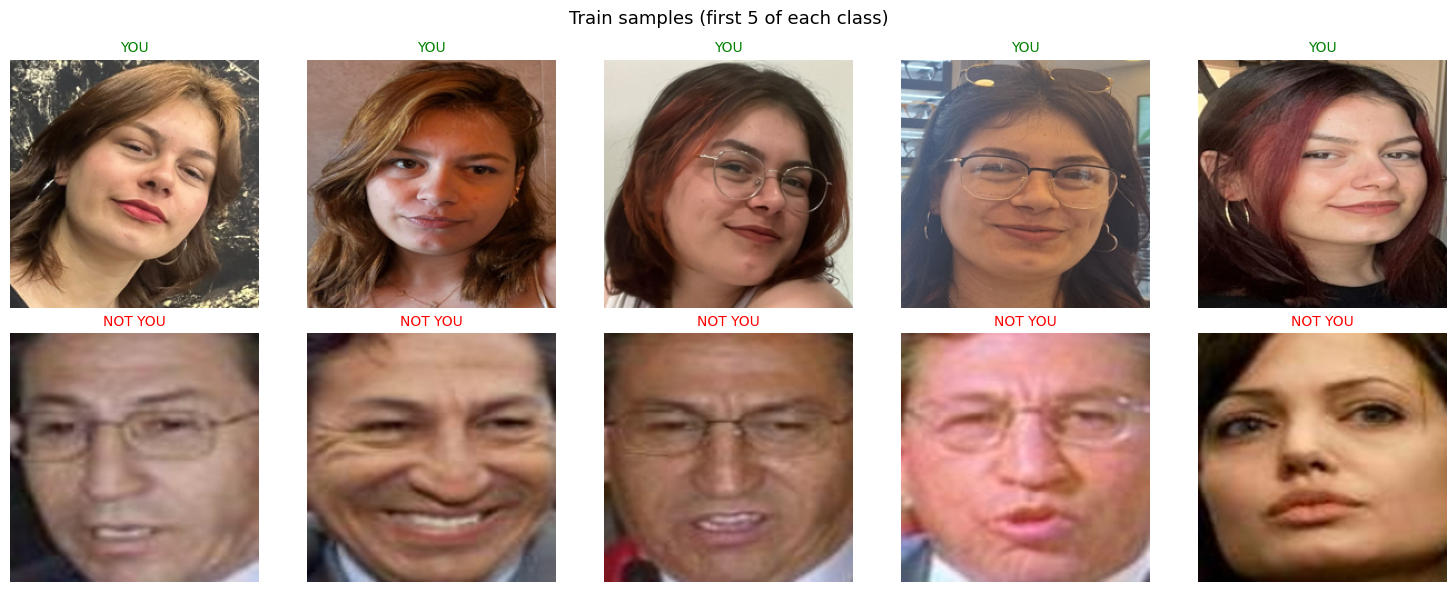

In [18]:
from PIL import Image

def show_samples(pos_folder, neg_folder, n=5, title='Train samples'):
    pos_paths = sorted(p for p in Path(pos_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]
    neg_paths = sorted(p for p in Path(neg_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle(title, fontsize=13)

    for i, (ax, path) in enumerate(zip(axes[0], pos_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('YOU', color='green', fontsize=10)
        ax.axis('off')

    for i, (ax, path) in enumerate(zip(axes[1], neg_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('NOT YOU', color='red', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(
    pos_folder=pos_dir / 'train',
    neg_folder=neg_dir / 'train',
    title='Train samples (first 5 of each class)',
)

## 3. Model

**YOUR TASK:** Open `src/model.py` and implement `build_model()`.

Run the sanity check below after implementing.

In [19]:
# Sanity check: run src/model.py
%run src/model.py

Running model sanity checks ...

  Total parameters     : 11,177,538
  Frozen parameters    : 11,176,512
  Trainable parameters : 1,026
  Trainable param count ✓
  Output shape torch.Size([4, 2]) ✓
  model.fc is trainable ✓

All model sanity checks passed.


**Q1**: What is transfer learning, and why do we freeze the backbone?

Transfer learning is using a pre-trained model in a different problem by making necessary adjustments based on different strategies. Such as making the last linear layer(head) learnable: feature extraction, or making the last couple of layers and head learnable: partial fine-tuning, or making all of the layers learnable (basically creating a cnn from scratch): full fine-tuning. We freeze the backbone because the model we used has been already trained and we want to update only the linear layer weights in order to have a shorter training time. That's why we freeze the backbone and carry on with only linear layer in terms of feature extraction.

**Q2**: We have only 20 personal training images. What risks does this create?

The dataset is too small for the model to actually learn. Hence it creates a risk for overfitting. It will perform well in both training and validation set but it performs worse when we use the test dataset, as the model has not learned but it memorized. Also having a small train set will result in poor when the model is integrated into real-world image classification. 

## 4. Training

**YOUR TASK:** Open `src/train.py` and implement `train_one_epoch()`.

Run training after implementing. You should see val accuracy rise above 0.8 within a few epochs.

In [20]:
import importlib
import train as train_module
importlib.reload(train_module)

history = train_module.run('config.json')

Device: cpu
Train batches: 3  |  Val batches: 1
Epoch   1/20  train_loss=0.6727  train_acc=0.5000  val_loss=0.6701  val_acc=0.7000
  ✓ Best model saved (val_acc=0.7000)
Epoch   2/20  train_loss=0.5840  train_acc=0.7500  val_loss=0.6217  val_acc=0.8000
  ✓ Best model saved (val_acc=0.8000)
Epoch   3/20  train_loss=0.4697  train_acc=0.9000  val_loss=0.5854  val_acc=0.6000
Epoch   4/20  train_loss=0.4268  train_acc=0.8750  val_loss=0.5999  val_acc=0.6000
Epoch   5/20  train_loss=0.3770  train_acc=0.8500  val_loss=0.4564  val_acc=0.8000
Epoch   6/20  train_loss=0.2452  train_acc=1.0000  val_loss=0.3464  val_acc=0.8000
Epoch   7/20  train_loss=0.2828  train_acc=0.9250  val_loss=0.2881  val_acc=1.0000
  ✓ Best model saved (val_acc=1.0000)
Epoch   8/20  train_loss=0.2377  train_acc=0.9750  val_loss=0.2652  val_acc=1.0000
Epoch   9/20  train_loss=0.1817  train_acc=0.9750  val_loss=0.2334  val_acc=1.0000
Epoch  10/20  train_loss=0.1431  train_acc=1.0000  val_loss=0.2126  val_acc=1.0000
Epoch  1

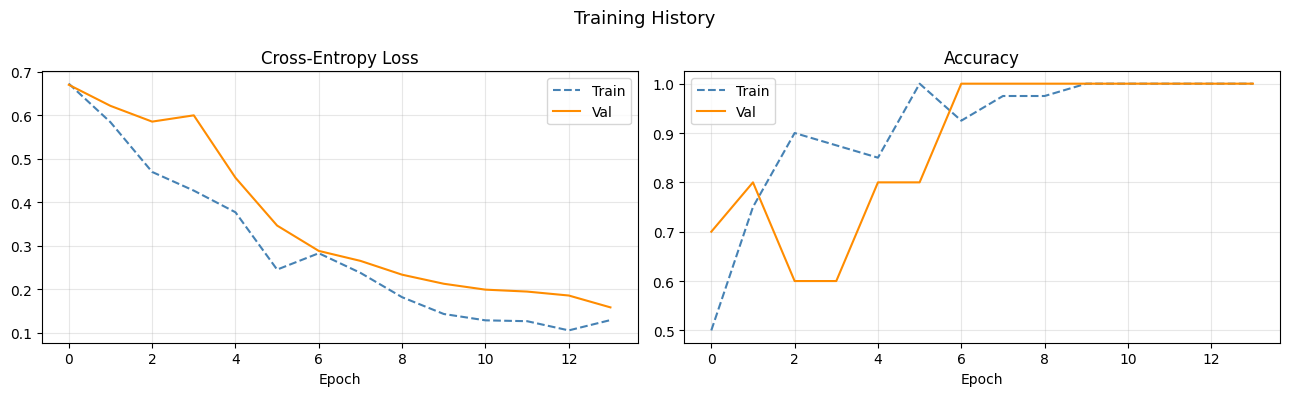

Best val accuracy : 1.0000


In [21]:
history = np.load('logs/history.npy', allow_pickle=True).item()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'acc'],
    ['Cross-Entropy Loss', 'Accuracy'],
):
    ax.plot(history[f'train_{metric}'], '--', color='steelblue',  label='Train')
    ax.plot(history[f'val_{metric}'],   '-',  color='darkorange', label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('logs/training_curves.png', dpi=150)
plt.show()

print(f'Best val accuracy : {max(history["val_acc"]):.4f}')

## 5. Evaluation

**YOUR TASK:** Open `src/evaluate.py` and implement `compute_metrics()`.

Treat label 1 (YOU) as the positive class. Run the sanity check first, then evaluate on the test set.

In [22]:
# Sanity check: run src/evaluate.py
%run src/evaluate.py

Running compute_metrics sanity checks ...

  Perfect-prediction check ✓
  All-negative edge case ✓
  Mixed-prediction check ✓

All compute_metrics sanity checks passed.


In [23]:
import importlib
import evaluate as eval_module
importlib.reload(eval_module)

from model import build_model
from dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best checkpoint
model = build_model(cfg['model']['backbone'], cfg['model']['num_classes'])
model.load_state_dict(torch.load('checkpoints/best_model.pt', map_location=device))
model = model.to(device)

# Get test DataLoader
_, _, test_loader = get_dataloaders(
    positive_dir=cfg['data']['positive_dir'],
    negative_dir=cfg['data']['negative_dir'],
    image_size=cfg['data']['image_size'],
    batch_size=cfg['training']['batch_size'],
)

# Run inference
probs, preds, labels = eval_module.predict_all(model, test_loader, device)
metrics = eval_module.compute_metrics(preds, labels)
eval_module.print_report(metrics, probs, labels)

Evaluation Report  (10 test images)
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

  #    True       P(YOU)    P(NOT YOU)   Pred
  --------------------------------------------------
  1    YOU        0.9427    0.0573       YOU ✓
  2    YOU        0.9445    0.0555       YOU ✓
  3    YOU        0.8920    0.1080       YOU ✓
  4    YOU        0.8925    0.1075       YOU ✓
  5    YOU        0.8882    0.1118       YOU ✓
  6    NOT YOU    0.2691    0.7309       NOT YOU ✓
  7    NOT YOU    0.4938    0.5062       NOT YOU ✓
  8    NOT YOU    0.1799    0.8201       NOT YOU ✓
  9    NOT YOU    0.1223    0.8777       NOT YOU ✓
  10   NOT YOU    0.1071    0.8929       NOT YOU ✓


**Q3**: What does precision capture that accuracy does not? What does recall capture?

The precision captures how many of the predicted positives are actually correct. We divide the true positive predictions to every positive prediction. It is used for the situations where the FP are costly. The accuracy doesn't capture this correctness of the predictions, it only captures the overall predictions being correct. The recall on the other hand captures how many actual positives were succesfully found. We divide the true positive predictions to overall occurrences of the label is true hence we observe how many of the true positives were found. It is used in the situations where the FN are costly.

**Q4**: What would happen to the reported test accuracy if you included test images
in the training set? Why does it invalidate the results?

It would invalidate the results because if we include the test data in the training set, then the model will learn the test data as well. Which will result in a higher test accuracy as we wanted but it doesn't show that the model's learning capacity is perfect. As the test data also has been learned, when we try another test set that is not included in the train set the accuracy will drop.

## 6. Gradio App

**YOUR TASK:** Open `src/app.py` and implement `predict()` and `build_app()`

After launching the app below:
1. Upload each of your **5 positive test images** one at a time.
2. Take a screenshot of each prediction showing both class probabilities.
3. Save them as `screenshots/screenshot_1.png` through `screenshots/screenshot_5.png`.

**Submit all 5 screenshots with your assignment.**

In [24]:
import importlib
import app as app_module
importlib.reload(app_module)

demo = app_module.build_app(config_path='config.json')
demo.launch()

Model loaded from checkpoints\best_model.pt (device: cpu)
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 7 Submission checklist

Before submitting, verify:
- [ ] The notebook has run succesfully and all the outputs are visible.
- [ ] All questions are answered.
- [ ] `screenshots/screenshot_1.png` — test image 1, both probabilities visible
- [ ] `screenshots/screenshot_2.png` — test image 2, both probabilities visible
- [ ] `screenshots/screenshot_3.png` — test image 3, both probabilities visible
- [ ] `screenshots/screenshot_4.png` — test image 4, both probabilities visible
- [ ] `screenshots/screenshot_5.png` — test image 5, both probabilities visible
- [ ] `data/` excluded from submission zip
- [ ] `checkpoints/` excluded from submission zip
- [ ] Random seed is still 42 in `config.json`